In [1]:
import os
import glob
import random
import numpy as np
import nibabel as nib
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.utils import Sequence

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-05-23 16:06:19.891695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779552380.076182      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779552380.128905      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779552380.549329      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779552380.549369      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779552380.549371      57 computation_placer.cc:177] computation placer alr

In [2]:

DATA_DIR = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

IMG_SIZE   = 256
N_CHANNELS = 3            
N_CLASSES  = 3            

SLICE_RANGE = (60, 130)  
MIN_TUMOR_PIXELS = 50 

BATCH_SIZE     = 8
EPOCHS         = 15
LEARNING_RATE  = 1e-4
VAL_SPLIT      = 0.1
WEIGHT_DECAY   = 1e-5

OUT_DIR    = "/kaggle/working/outputs"
MODEL_PATH = "/kaggle/working/outputs/attention_effnetb3_best.keras"

os.makedirs(OUT_DIR, exist_ok=True)



In [3]:

def find_patient_dirs(root):
    patient_dirs = []
    for d in sorted(glob.glob(os.path.join(root, "*"))):
        if not os.path.isdir(d):
            continue
        if glob.glob(os.path.join(d, "*_seg.nii*")):
            patient_dirs.append(d)
    return patient_dirs


def load_nii(path):
    return nib.load(path).get_fdata()


def get_modality_paths(patient_dir):
    def _find(suffix):
        hits = glob.glob(os.path.join(patient_dir, f"*_{suffix}.nii*"))
        return hits[0] if hits else None
    return _find("flair"), _find("t1ce"), _find("t2"), _find("seg")


def normalize_slice(slc):
    slc = slc.astype(np.float32)
    mn, mx = np.min(slc), np.max(slc)
    if mx - mn < 1e-6:
        return np.zeros_like(slc, dtype=np.uint8)
    slc = (slc - mn) / (mx - mn) * 255.0
    return slc.astype(np.uint8)


def apply_clahe_and_blur(rgb_uint8):
    lab = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    blurred = cv2.GaussianBlur(bgr, (3, 3), 0)
    return blurred


def brats_seg_to_three_masks(seg_slice):
    wt = np.isin(seg_slice, [1, 2, 4]).astype(np.float32)
    tc = np.isin(seg_slice, [1, 4]).astype(np.float32)
    et = (seg_slice == 4).astype(np.float32)
    return np.stack([wt, tc, et], axis=-1)


def extract_slices_from_volume(patient_dir):
    flair_p, t1ce_p, t2_p, seg_p = get_modality_paths(patient_dir)
    if not all([flair_p, t1ce_p, t2_p, seg_p]):
        return None, None

    flair = load_nii(flair_p)
    t1ce  = load_nii(t1ce_p)
    t2    = load_nii(t2_p)
    seg   = load_nii(seg_p)

    X_list, Y_list = [], []
    z_start, z_end = SLICE_RANGE
    z_end = min(z_end, flair.shape[2])

    for z in range(z_start, z_end):
        seg_slc = seg[:, :, z]
        if np.sum(seg_slc > 0) < MIN_TUMOR_PIXELS:
            continue  

        ch_flair = normalize_slice(flair[:, :, z])
        ch_t1ce  = normalize_slice(t1ce[:, :, z])
        ch_t2    = normalize_slice(t2[:, :, z])
        rgb = np.stack([ch_flair, ch_t1ce, ch_t2], axis=-1) 

        rgb_pp = apply_clahe_and_blur(rgb)

        rgb_resized = cv2.resize(rgb_pp, (IMG_SIZE, IMG_SIZE),
                                 interpolation=cv2.INTER_LINEAR)
        rgb_resized = rgb_resized.astype(np.float32) / 255.0

        mask = brats_seg_to_three_masks(seg_slc)
        mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                                  interpolation=cv2.INTER_NEAREST)

        X_list.append(rgb_resized)
        Y_list.append(mask_resized.astype(np.float32))

    if not X_list:
        return None, None
    return np.stack(X_list), np.stack(Y_list)

In [4]:
class BraTSSequence(Sequence):
    """Loads patient volumes on the fly. Buffers a few patients' slices at a time."""

    def __init__(self, patient_dirs, batch_size=8, shuffle=True,
                 patients_per_buffer=4, **kwargs):
        super().__init__(**kwargs)
        self.patient_dirs = list(patient_dirs)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.patients_per_buffer = patients_per_buffer
        self._buffer_X, self._buffer_Y = None, None
        self._buffer_idx = 0
        self._patient_cursor = 0

        self._steps = self._estimate_steps()
        self.on_epoch_end()

    def _estimate_steps(self):
        # Each patient yields roughly 40-50 tumor-bearing slices; assume ~30 to be safe
        approx_slices = len(self.patient_dirs) * 30
        return max(1, approx_slices // self.batch_size)

    def __len__(self):
        return self._steps

    def on_epoch_end(self):
        if self.shuffle:
            random.shuffle(self.patient_dirs)
        self._buffer_X, self._buffer_Y = None, None
        self._buffer_idx = 0
        self._patient_cursor = 0

    def _refill_buffer(self):
        Xs, Ys = [], []
        loaded = 0
        while loaded < self.patients_per_buffer and self._patient_cursor < len(self.patient_dirs):
            p = self.patient_dirs[self._patient_cursor]
            self._patient_cursor += 1
            X, Y = extract_slices_from_volume(p)
            if X is not None:
                Xs.append(X)
                Ys.append(Y)
                loaded += 1
        if not Xs:
            self._patient_cursor = 0
            return self._refill_buffer() if loaded == 0 and len(self.patient_dirs) > 0 else (None, None)
        X = np.concatenate(Xs, axis=0)
        Y = np.concatenate(Ys, axis=0)
        
        perm = np.random.permutation(len(X))
        return X[perm], Y[perm]

    def __getitem__(self, idx):
        if (self._buffer_X is None
                or self._buffer_idx + self.batch_size > len(self._buffer_X)):
            self._buffer_X, self._buffer_Y = self._refill_buffer()
            self._buffer_idx = 0
            if self._buffer_X is None:
                return (np.zeros((self.batch_size, IMG_SIZE, IMG_SIZE, 3), np.float32),
                        np.zeros((self.batch_size, IMG_SIZE, IMG_SIZE, N_CLASSES), np.float32))

        bx = self._buffer_X[self._buffer_idx:self._buffer_idx + self.batch_size]
        by = self._buffer_Y[self._buffer_idx:self._buffer_idx + self.batch_size]
        self._buffer_idx += self.batch_size
        return bx, by

In [5]:
def multi_scale_attention_block(x, gating, filters, name):
    theta1 = layers.Conv2D(filters, 1, padding="same", name=f"{name}_theta1")(x)
    theta3 = layers.Conv2D(filters, 3, padding="same", name=f"{name}_theta3")(x)
    theta5 = layers.Conv2D(filters, 5, padding="same", name=f"{name}_theta5")(x)
    theta  = layers.Concatenate(name=f"{name}_concat")([theta1, theta3, theta5])
    theta  = layers.Conv2D(filters, 1, padding="same", name=f"{name}_theta_proj")(theta)

    phi_g = layers.Conv2D(filters, 1, padding="same", name=f"{name}_phi_g")(gating)

    if phi_g.shape[1] != theta.shape[1] or phi_g.shape[2] != theta.shape[2]:
        phi_g = layers.UpSampling2D(
            size=(theta.shape[1] // phi_g.shape[1], theta.shape[2] // phi_g.shape[2]),
            interpolation="bilinear", name=f"{name}_phi_up")(phi_g)

    a = layers.Add(name=f"{name}_add")([theta, phi_g])
    a = layers.ReLU(name=f"{name}_relu")(a)
    psi = layers.Conv2D(1, 1, padding="same", activation="sigmoid",
                        name=f"{name}_psi")(a)

    x_att = layers.Multiply(name=f"{name}_mult")([x, psi])
    return x_att


def residual_conv_block(x, filters, name):
    shortcut = layers.Conv2D(filters, 1, padding="same",
                             name=f"{name}_shortcut")(x)
    y = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv1")(x)
    y = layers.BatchNormalization(name=f"{name}_bn1")(y)
    y = layers.ReLU(name=f"{name}_relu1")(y)
    y = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv2")(y)
    y = layers.BatchNormalization(name=f"{name}_bn2")(y)
    y = layers.Add(name=f"{name}_resadd")([y, shortcut])
    y = layers.ReLU(name=f"{name}_relu2")(y)
    return y


def decoder_block(x, skip, filters, name):

    up = layers.Conv2DTranspose(filters, 2, strides=2, padding="same",
                                name=f"{name}_upconv")(x)
    skip_att = multi_scale_attention_block(skip, up, filters,
                                           name=f"{name}_msa")
    merged = layers.Concatenate(name=f"{name}_concat")([up, skip_att])
    out = residual_conv_block(merged, filters, name=f"{name}_resblock")
    return out


def build_msau_efficientnetb3(input_shape=(256, 256, 3), n_classes=3):
    inputs = Input(shape=input_shape, name="input_image")

    base = EfficientNetB3(include_top=False, weights="imagenet",
                          input_tensor=inputs)

    skip1 = base.get_layer("block2a_expand_activation").output   # 128
    skip2 = base.get_layer("block3a_expand_activation").output   # 64
    skip3 = base.get_layer("block4a_expand_activation").output   # 32
    skip4 = base.get_layer("block6a_expand_activation").output   # 16
    bottleneck = base.get_layer("top_activation").output         # 8

    d4 = decoder_block(bottleneck, skip4, 256, name="dec4")  # 16x16
    d3 = decoder_block(d4,         skip3, 128, name="dec3")  # 32x32
    d2 = decoder_block(d3,         skip2, 64,  name="dec2")  # 64x64
    d1 = decoder_block(d2,         skip1, 32,  name="dec1")  # 128x128

    d0 = layers.Conv2DTranspose(16, 2, strides=2, padding="same",
                                name="dec0_upconv")(d1)         # 256x256
    d0 = residual_conv_block(d0, 16, name="dec0_resblock")

    outputs = layers.Conv2D(n_classes, 1, padding="same",
                            activation="sigmoid", name="output_mask")(d0)

    return Model(inputs, outputs, name="MSAU_EfficientNetB3")

In [6]:
SMOOTH = 1e-6

def dice_coef(y_true, y_pred, smooth=SMOOTH):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * inter + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=SMOOTH):
    y_pred_b = tf.cast(y_pred > 0.5, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred_b, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - inter
    return (inter + smooth) / (union + smooth)

def precision_metric(y_true, y_pred, smooth=SMOOTH):
    y_pred_b = tf.cast(y_pred > 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred_b)
    fp = tf.reduce_sum((1 - y_true) * y_pred_b)
    return (tp + smooth) / (tp + fp + smooth)

def recall_metric(y_true, y_pred, smooth=SMOOTH):
    y_pred_b = tf.cast(y_pred > 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred_b)
    fn = tf.reduce_sum(y_true * (1 - y_pred_b))
    return (tp + smooth) / (tp + fn + smooth)

def specificity_metric(y_true, y_pred, smooth=SMOOTH):
    y_pred_b = tf.cast(y_pred > 0.5, tf.float32)
    tn = tf.reduce_sum((1 - y_true) * (1 - y_pred_b))
    fp = tf.reduce_sum((1 - y_true) * y_pred_b)
    return (tn + smooth) / (tn + fp + smooth)

In [7]:
def evaluate_all_metrics(model, sequence, n_batches=None):

    class_names = ["WT", "TC", "ET"]
    n_classes = N_CLASSES

    tp = np.zeros(n_classes, dtype=np.float64)
    fp = np.zeros(n_classes, dtype=np.float64)
    fn = np.zeros(n_classes, dtype=np.float64)
    tn = np.zeros(n_classes, dtype=np.float64)

    total = n_batches if n_batches is not None else len(sequence)
    for i in tqdm(range(total), desc="Evaluating"):
        x, y = sequence[i]
        p = model.predict(x, verbose=0)
        p_bin = (p > 0.5).astype(np.float32)

        for c in range(n_classes):
            yt = y[..., c]
            yp = p_bin[..., c]
            tp[c] += np.sum(yt * yp)
            fp[c] += np.sum((1 - yt) * yp)
            fn[c] += np.sum(yt * (1 - yp))
            tn[c] += np.sum((1 - yt) * (1 - yp))

    eps = 1e-7
    results = {}
    for c, name in enumerate(class_names):
        accuracy = (tp[c] + tn[c]) / (tp[c] + tn[c] + fp[c] + fn[c] + eps)
        mcr      = (fp[c] + fn[c]) / (tp[c] + tn[c] + fp[c] + fn[c] + eps)
        dsc      = (2 * tp[c]) / (2 * tp[c] + fp[c] + fn[c] + eps)
        iou      = tp[c] / (tp[c] + fp[c] + fn[c] + eps)
        precision = tp[c] / (tp[c] + fp[c] + eps)
        recall    = tp[c] / (tp[c] + fn[c] + eps)
        specificity = tn[c] / (tn[c] + fp[c] + eps)
        results[name] = {
            "Accuracy": accuracy, "MCR": mcr, "DSC": dsc, "IoU": iou,
            "Precision": precision, "Recall": recall, "Specificity": specificity,
        }

    keys = ["Accuracy", "MCR", "DSC", "IoU", "Precision", "Recall", "Specificity"]
    overall = {k: float(np.mean([results[c][k] for c in class_names])) for k in keys}
    overall["Mean IoU"] = float(np.mean([results[c]["IoU"] for c in class_names]))
    results["Overall"] = overall
    return results


def print_metrics_table(results):
    print("\n" + "=" * 78)
    print(f"{'Metric':<14}" + "".join(f"{c:>14}" for c in ["WT", "TC", "ET", "Overall"]))
    print("-" * 78)
    for m in ["Accuracy", "MCR", "DSC", "IoU", "Precision", "Recall", "Specificity"]:
        row = f"{m:<14}"
        for c in ["WT", "TC", "ET", "Overall"]:
            row += f"{results[c][m]:>14.4f}"
        print(row)
    print(f"{'Mean IoU':<14}{'':>42}{results['Overall']['Mean IoU']:>14.4f}")
    print("=" * 78)

In [8]:
def plot_training_history(history, out_path):
    metrics = [
        ("dice_coef",        "val_dice_coef",        "Dice Coefficient"),
        ("loss",             "val_loss",             "Dice Loss"),
        ("precision_metric", "val_precision_metric", "Precision"),
        ("recall_metric",    "val_recall_metric",    "Recall"),
        ("iou_metric",       "val_iou_metric",       "IoU"),
        ("specificity_metric","val_specificity_metric","Specificity"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, (tr, va, title) in zip(axes.flat, metrics):
        if tr in history.history:
            ax.plot(history.history[tr],  label=f"Train {title}", linewidth=2)
        if va in history.history:
            ax.plot(history.history[va], label=f"Val {title}", linewidth=2)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle("Training metrics — MSA U-Net with EfficientNetB3", fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()


def visualize_predictions(model, sequence, out_path, n_samples=4):
    x, y = sequence[0]
    p = model.predict(x[:n_samples], verbose=0)
    fig, axes = plt.subplots(n_samples, 5, figsize=(18, 3.5 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]
    for i in range(n_samples):
        axes[i, 0].imshow(x[i]);                  axes[i, 0].set_title("Input (FLAIR/T1ce/T2)")
        axes[i, 1].imshow(y[i, ..., 0], cmap="Reds");   axes[i, 1].set_title("GT Whole Tumor")
        axes[i, 2].imshow(y[i, ..., 1], cmap="Greens"); axes[i, 2].set_title("GT Tumor Core")
        axes[i, 3].imshow(y[i, ..., 2], cmap="Blues");  axes[i, 3].set_title("GT Enhancing")
        overlay = np.zeros((IMG_SIZE, IMG_SIZE, 3))
        overlay[..., 0] = (p[i, ..., 0] > 0.5)     # R = WT
        overlay[..., 1] = (p[i, ..., 1] > 0.5)     # G = TC
        overlay[..., 2] = (p[i, ..., 2] > 0.5)     # B = ET
        axes[i, 4].imshow(overlay);               axes[i, 4].set_title("Predicted (R=WT, G=TC, B=ET)")
        for j in range(5):
            axes[i, j].axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

In [9]:
patient_dirs = find_patient_dirs(DATA_DIR)
print(f"Found {len(patient_dirs)} patients.")

Found 368 patients.


In [10]:
random.shuffle(patient_dirs)
n_test = max(1, int(0.1 * len(patient_dirs)))
test_dirs = patient_dirs[:n_test]
trainval_dirs = patient_dirs[n_test:]
n_val = max(1, int(VAL_SPLIT * len(trainval_dirs)))
val_dirs   = trainval_dirs[:n_val]
train_dirs = trainval_dirs[n_val:]
print(f"Train: {len(train_dirs)} | Val: {len(val_dirs)} | Test: {len(test_dirs)}")

train_seq = BraTSSequence(train_dirs, batch_size=BATCH_SIZE, shuffle=True)
val_seq   = BraTSSequence(val_dirs,   batch_size=BATCH_SIZE, shuffle=False)
test_seq  = BraTSSequence(test_dirs,  batch_size=BATCH_SIZE, shuffle=False)

Train: 299 | Val: 33 | Test: 36


In [11]:
print("Building Attention U-Net with EfficientNetB3 encoder")
model = build_msau_efficientnetb3(
    input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
    n_classes=N_CLASSES,
)
model.compile(
    optimizer=AdamW(learning_rate=LEARNING_RATE,
                    weight_decay=WEIGHT_DECAY,
                    beta_1=0.9, beta_2=0.999, epsilon=1e-8),
    loss=dice_loss,
    metrics=[dice_coef, iou_metric, precision_metric,
             recall_metric, specificity_metric],
)
model.summary(line_length=110)

Building Attention U-Net with EfficientNetB3 encoder


I0000 00:00:1779552405.874089      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MSAU_EfficientNetB3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape              ┃          Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)       │ (None, 256, 256, 3)       │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ rescaling (Rescaling)          │ (None, 256, 256, 3)       │                0 │ input_image[0][0]          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ normalization (Normalization)  │ (None, 256, 256, 3)       │                7 │ rescaling[0][0]            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)        │ (None, 256, 256, 3)       │                0 │ normalization[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D)  │ (None, 257, 257, 3)       │                0 │ rescaling_1[0][0]          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)             │ (None, 128, 128, 40)      │            1,080 │ stem_conv_pad[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)   │ (None, 128, 128, 40)      │              160 │ stem_conv[0][0]            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ stem_activation (Activation)   │ (None, 128, 128, 40)      │                0 │ stem_bn[0][0]              │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_dwconv                 │ (None, 128, 128, 40)      │              360 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)              │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_bn                     │ (None, 128, 128, 40)      │              160 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_activation             │ (None, 128, 128, 40)      │                0 │ block1a_bn[0][0]           │
│ (Activation)                   │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_se_squeeze             │ (None, 40)                │                0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)       │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)   │ (None, 1, 1, 40)          │                0 │ block1a_se_squeeze[0][0]   │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)     │ (None, 1, 1, 10)          │              410 │ block1a_se_reshape[0][0]   │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)     │ (None, 1, 1, 40)          │              440 │ block1a_se_reduce[0][0]    │
├───

 Total params: 26,365,670 (100.58 MB)

 Trainable params: 26,276,383 (100.24 MB)

 Non-trainable params: 89,287 (348.78 KB)

In [12]:
callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5,
                      min_lr=1e-7, verbose=1),
    EarlyStopping(monitor="val_loss", patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor="val_dice_coef", mode="max",
                    save_best_only=True, verbose=1),
]

In [13]:
print("Starting training")
history = model.fit(
    train_seq, validation_data=val_seq,
    epochs=EPOCHS, callbacks=callbacks, verbose=1,
)

Starting training
Epoch 1/15


I0000 00:00:1779552488.540841     128 service.cc:152] XLA service 0x7df5f8002b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779552488.540923     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779552500.826275     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-23 16:08:43.807621: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 16:08:44.000733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-23 16:08:44.454808: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

1121/1121 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - dice_coef: 0.4981 - iou_metric: 0.4329 - loss: 0.5019 - precision_metric: 0.5352 - recall_metric: 0.7900 - specificity_metric: 0.9382
Epoch 1: val_dice_coef improved from -inf to 0.70429, saving model to /kaggle/working/outputs/attention_effnetb3_best.keras
1121/1121 ━━━━━━━━━━━━━━━━━━━━ 448s 248ms/step - dice_coef: 0.4983 - iou_metric: 0.4331 - loss: 0.5017 - precision_metric: 0.5354 - recall_metric: 0.7900 - specificity_metric: 0.9383 - val_dice_coef: 0.7043 - val_iou_metric: 0.5511 - val_loss: 0.2957 - val_precision_metric: 0.9170 - val_recall_metric: 0.5827 - val_specificity_metric: 0.9992 - learning_rate: 1.0000e-04
Epoch 2/15
1121/1121 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - dice_coef: 0.8420 - iou_metric: 0.7362 - loss: 0.1580 - precision_metric: 0.8653 - recall_metric: 0.8364 - specificity_metric: 0.9981
Epoch 2: val_dice_coef did not improve from 0.70429
1121/1121 ━━━━━━━━━━━━━━━━━━━━ 239s 211ms/step - dice_coef: 0.8420 - iou_metric:

Plotting training curves


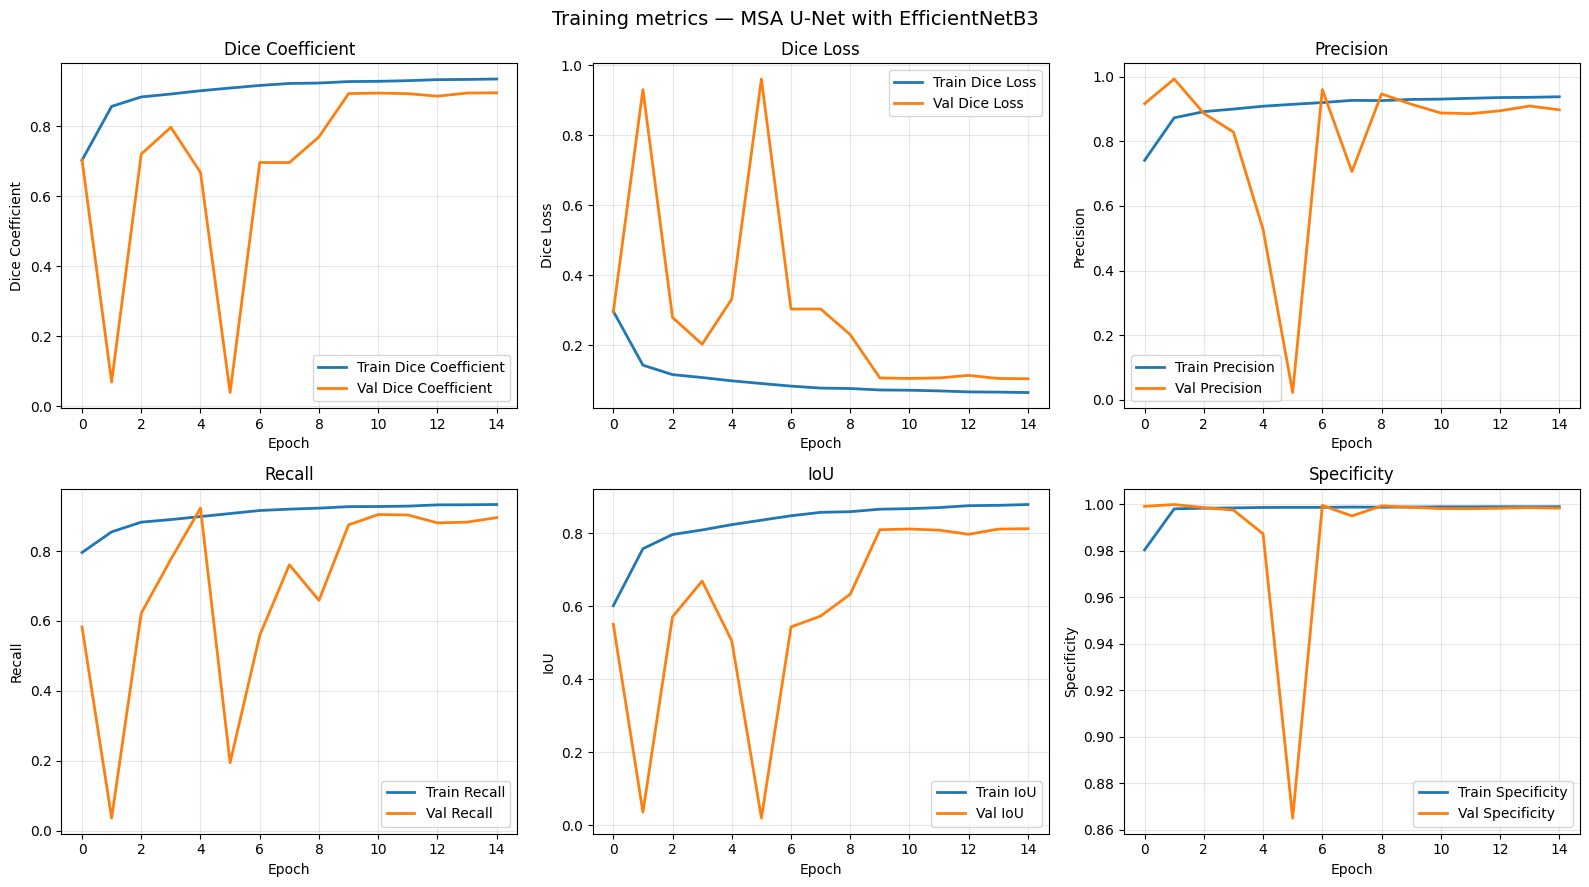

In [14]:
print("Plotting training curves")
plot_training_history(history, os.path.join(OUT_DIR, "training_curves.png"))

In [16]:
print("Evaluating on test set")
results = evaluate_all_metrics(model, test_seq)
print_metrics_table(results)

Evaluating on test set


Evaluating: 100%|██████████| 135/135 [00:58<00:00,  2.30it/s]


Metric                    WT            TC            ET       Overall
------------------------------------------------------------------------------
Accuracy              0.9948        0.9967        0.9980        0.9965
MCR                   0.0052        0.0033        0.0020        0.0035
DSC                   0.9102        0.8895        0.8571        0.8856
IoU                   0.8352        0.8009        0.7500        0.7954
Precision             0.9495        0.9523        0.8730        0.9250
Recall                0.8740        0.8344        0.8418        0.8501
Specificity           0.9985        0.9993        0.9991        0.9990
Mean IoU                                                        0.7954


In [18]:
import json
with open(os.path.join(OUT_DIR, "test_metrics.json"), "w") as f:
    json.dump(results, f, indent=2)

Sample predictions


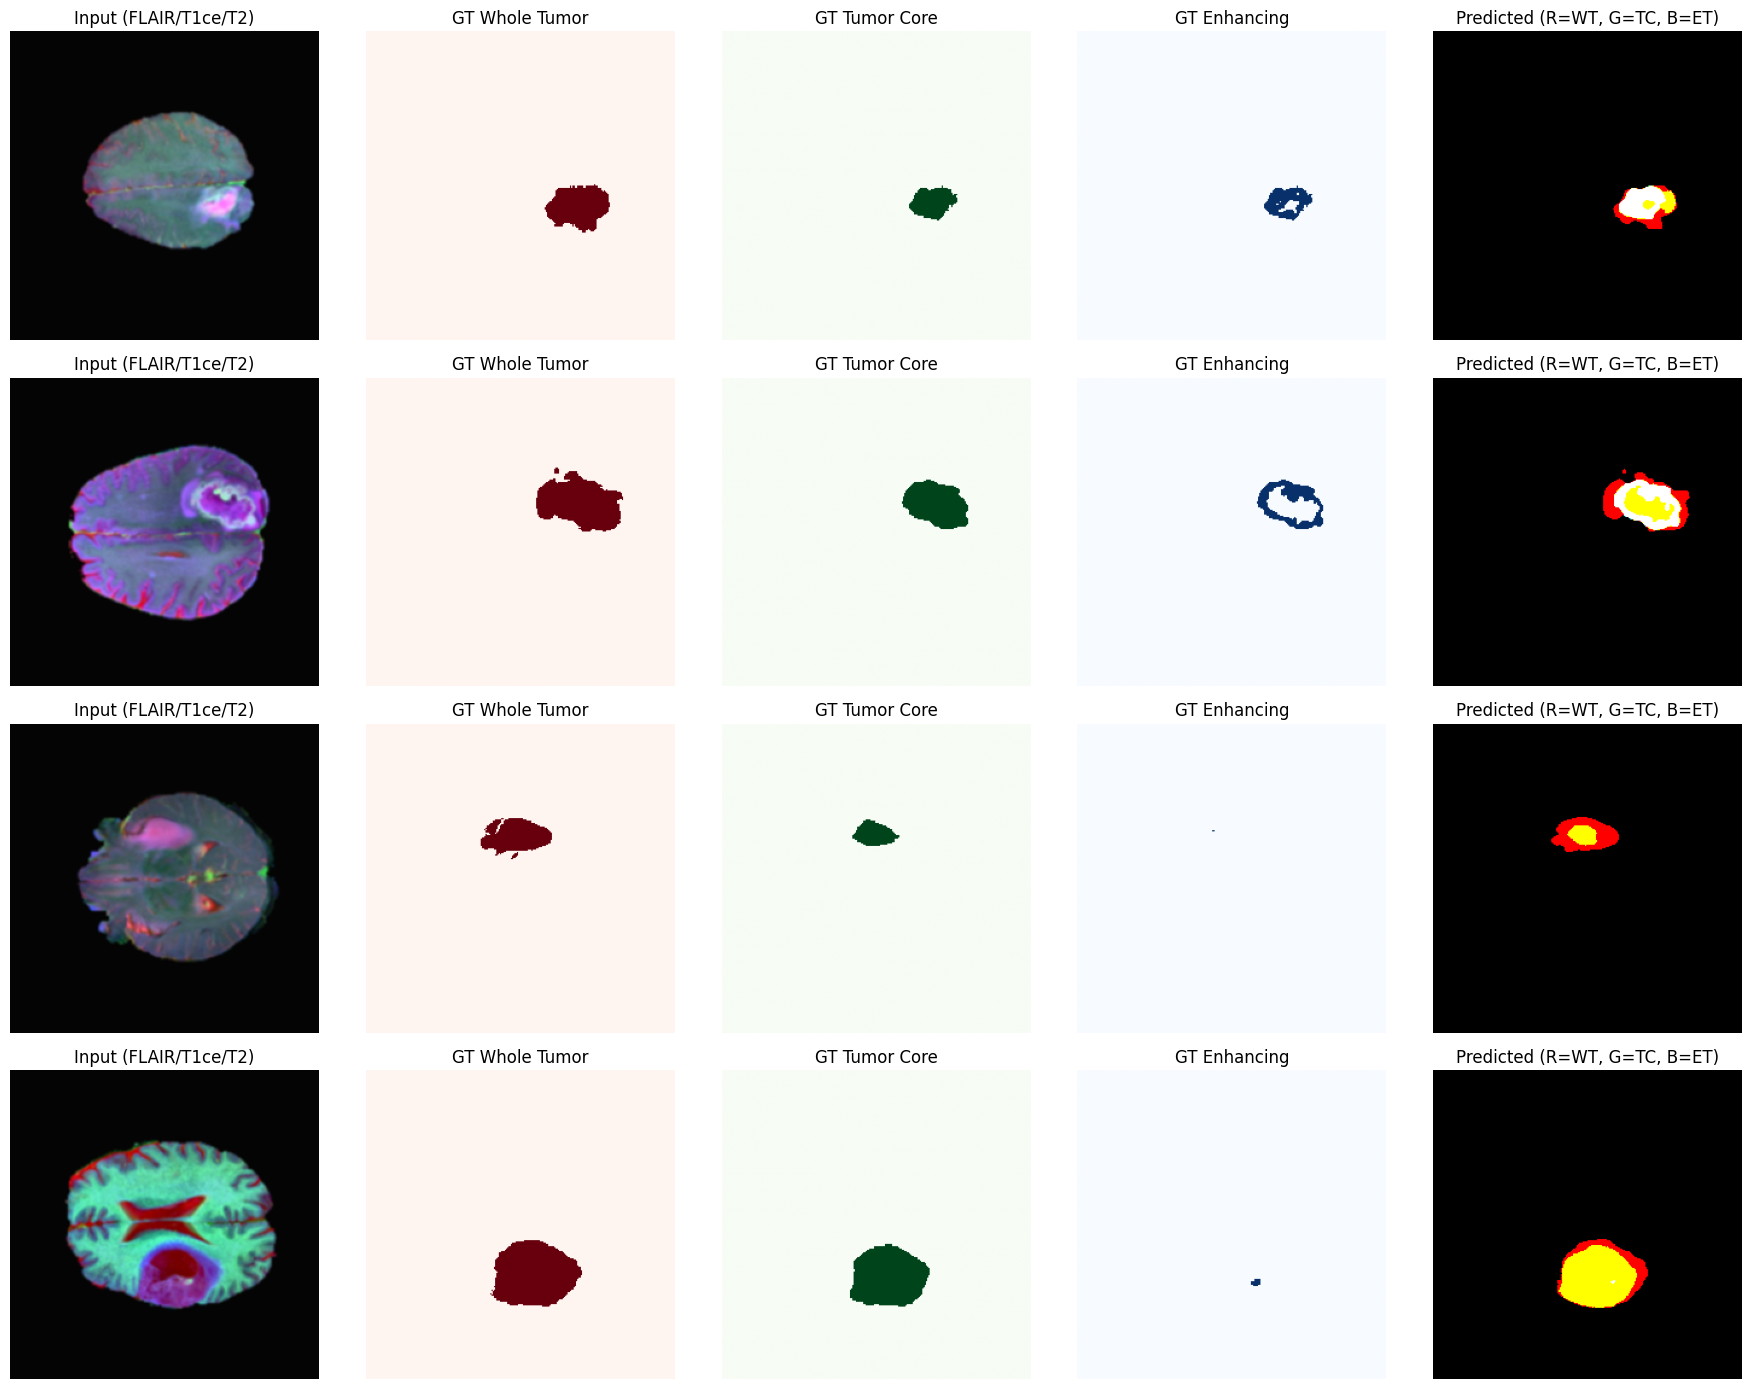

In [17]:
print("Sample predictions")
visualize_predictions(model, test_seq,
                      os.path.join(OUT_DIR, "sample_predictions.png"))